# **Capítulo 2: Eliminación de Ruido con Filtros Clásicos**

```
 Libro:  Procesamiento Digital de Voz e Imágenes en la Era de la Inteligencia Artificial
```


**Autor:  Dora María Ballesteros Larrotta**  
Universidad Militar Nueva Granada (UMNG)

---

### Material complementario del libro

Este notebook acompaña el **Capítulo 2** y contiene los ejemplos desarrollados a lo largo del texto. Se recomienda seguir el mismo orden del libro para obtener el máximo provecho de las actividades propuestas.

---

# **Ejemplo 11. Lectura y visualización en el dominio del tiempo y la frecuencia de una señal de voz**

Frecuencia de muestreo: 8000 Hz
Número de muestras: 24000
Duración: 3.00 segundos


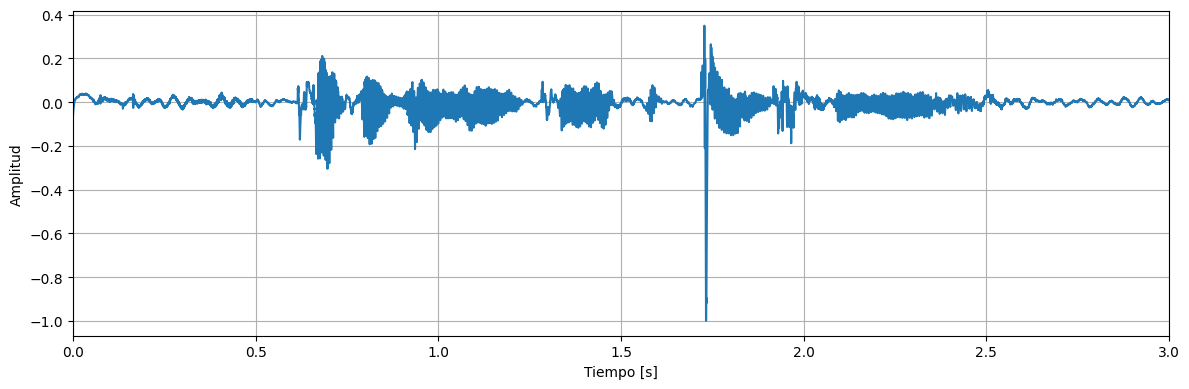

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import librosa

audio_file = "audio.wav"   # reemplazar por la ruta del archivo

x, fs = librosa.load(audio_file, sr=None) # hacer sr=None para preservar fs
x_norm = x / np.max(np.abs(x)) # normalizar el audio

N = len(x_norm) # total de muestras del audio
duracion = N / fs # duración en segundos del audio

print(f"Frecuencia de muestreo: {fs} Hz")
print(f"Número de muestras: {N}")
print(f"Duración: {duracion:.2f} segundos")

t = np.arange(N) / fs

plt.figure(figsize=(12,4))
plt.plot(t, x_norm)
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.grid(True)
plt.xlim([0, duracion])
plt.tight_layout()
plt.show()

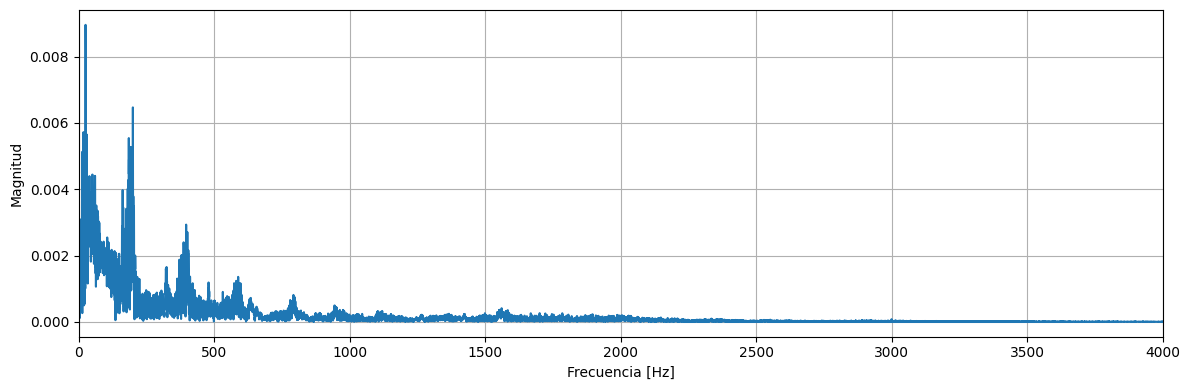

Tres picos principales del espectro:

Pico 1: Frecuencia = 25.00 Hz, Magnitud = 0.008958
Pico 2: Frecuencia = 199.67 Hz, Magnitud = 0.006468
Pico 3: Frecuencia = 17.33 Hz, Magnitud = 0.005722


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import librosa
from scipy.fft import rfft, rfftfreq
from scipy.signal import find_peaks

N = len(x_norm)
X = rfft(x_norm)
f = rfftfreq(N, d=1/fs)
mag = np.abs(X) / N # Magnitud normalizada
mag[1:-1] = 2 * mag[1:-1] # Corrección para espectro unilateral

plt.figure(figsize=(12,4)); plt.plot(f, mag)
plt.xlabel('Frecuencia [Hz]'); plt.ylabel('Magnitud')
plt.grid(True); plt.xlim([0, fs/2])
plt.tight_layout(); plt.show()

picos, propiedades = find_peaks(
    mag,
    height=0.001,      # altura mínima del pico
    distance=20        # separación mínima entre picos, en muestras del espectro
)

frecuencias_picos = f[picos]
magnitudes_picos = mag[picos]

idx = np.argsort(magnitudes_picos)[::-1]   # ordenado de mayor a menor
print("Tres picos principales del espectro:\n")

for i in range(min(3, len(idx))):
    k = idx[i]
    print(
        f"Pico {i+1}: "
        f"Frecuencia = {frecuencias_picos[k]:.2f} Hz, "
        f"Magnitud = {magnitudes_picos[k]:.6f}"
    )

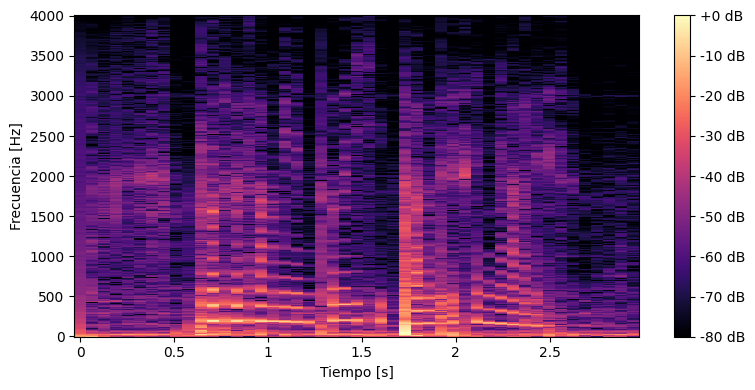

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display

n_fft = 1024
hop_length = 512
n_mels = 128

# Espectrograma logarítmico
S = np.abs(librosa.stft(x, n_fft=n_fft, hop_length=hop_length))**2
S_db = librosa.power_to_db(S, ref=np.max)

plt.figure(figsize=(8, 4))
librosa.display.specshow(
    S_db,
    sr=fs,
    hop_length=hop_length,
    x_axis="time",
    y_axis="hz"
)
plt.colorbar(format="%+2.0f dB")
plt.xlabel("Tiempo [s]")
plt.ylabel("Frecuencia [Hz]")
plt.tight_layout()
plt.show()


# **Ejemplo 12. Análisis de la señal de voz con ruido**

Frecuencia de muestreo: 8000 Hz
Número de muestras: 24000
Duración: 3.00 segundos


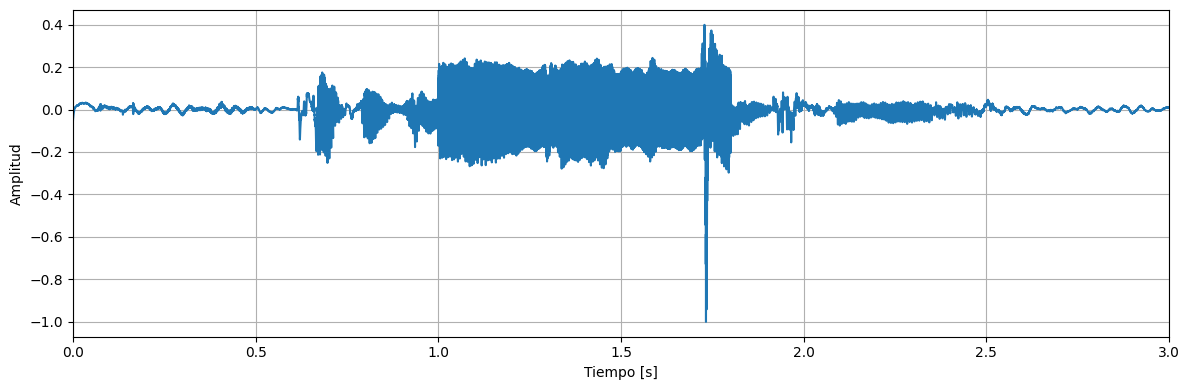

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import librosa

audio_file = "audio_noisy.wav"   # reemplazar por la ruta del archivo

x, fs = librosa.load(audio_file, sr=None) # hacer sr=None para preservar fs
x_norm = x / np.max(np.abs(x)) # normalizar el audio

N = len(x_norm) # total de muestras del audio
duracion = N / fs # duración en segundos del audio

print(f"Frecuencia de muestreo: {fs} Hz")
print(f"Número de muestras: {N}")
print(f"Duración: {duracion:.2f} segundos")

t = np.arange(N) / fs

plt.figure(figsize=(12,4))
plt.plot(t, x_norm)
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.grid(True)
plt.xlim([0, duracion])
plt.tight_layout()
plt.show()

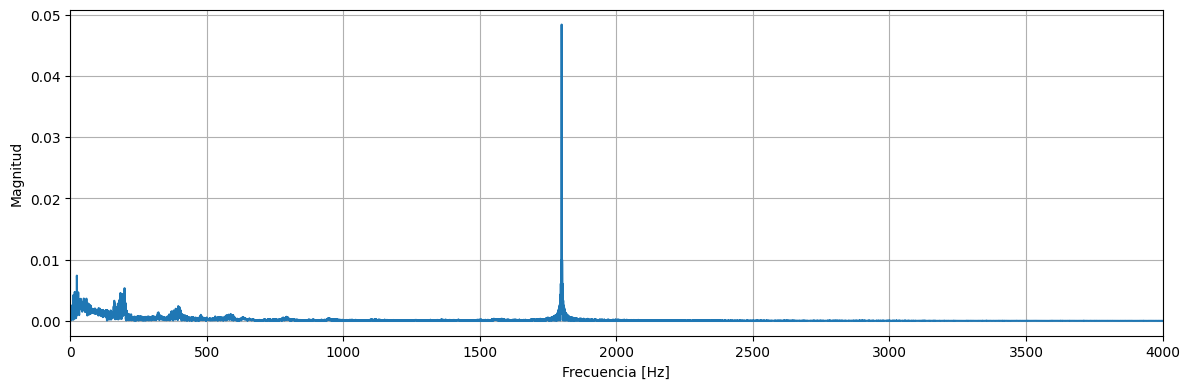

Tres picos principales del espectro:

Pico 1: Frecuencia = 1800.00 Hz, Magnitud = 0.048397
Pico 2: Frecuencia = 25.00 Hz, Magnitud = 0.007395
Pico 3: Frecuencia = 199.67 Hz, Magnitud = 0.005344


In [5]:
N = len(x_norm)
X = rfft(x_norm)
f = rfftfreq(N, d=1/fs)
mag = np.abs(X) / N # Magnitud normalizada
mag[1:-1] = 2 * mag[1:-1] # Corrección para espectro unilateral

plt.figure(figsize=(12,4)); plt.plot(f, mag)
plt.xlabel('Frecuencia [Hz]'); plt.ylabel('Magnitud')
plt.grid(True); plt.xlim([0, fs/2])
plt.tight_layout(); plt.show()

picos, propiedades = find_peaks(
    mag,
    height=0.001,      # altura mínima del pico
    distance=20        # separación mínima entre picos, en muestras del espectro
)

frecuencias_picos = f[picos]
magnitudes_picos = mag[picos]

idx = np.argsort(magnitudes_picos)[::-1]   # ordenado de mayor a menor
print("Tres picos principales del espectro:\n")

for i in range(min(3, len(idx))):
    k = idx[i]
    print(
        f"Pico {i+1}: "
        f"Frecuencia = {frecuencias_picos[k]:.2f} Hz, "
        f"Magnitud = {magnitudes_picos[k]:.6f}"
    )

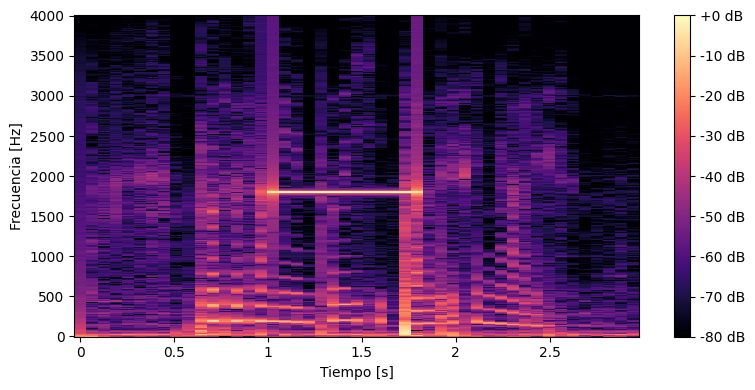

In [6]:
n_fft = 1024
hop_length = 512
n_mels = 128

# Espectrograma logarítmico
S = np.abs(librosa.stft(x, n_fft=n_fft, hop_length=hop_length))**2
S_db = librosa.power_to_db(S, ref=np.max)

plt.figure(figsize=(8, 4))
librosa.display.specshow(
    S_db,
    sr=fs,
    hop_length=hop_length,
    x_axis="time",
    y_axis="hz"
)
plt.colorbar(format="%+2.0f dB")
plt.xlabel("Tiempo [s]")
plt.ylabel("Frecuencia [Hz]")
plt.tight_layout()
plt.show()

# **Ejemplo 13.  Filtrado de la señal con filtro de promedio**

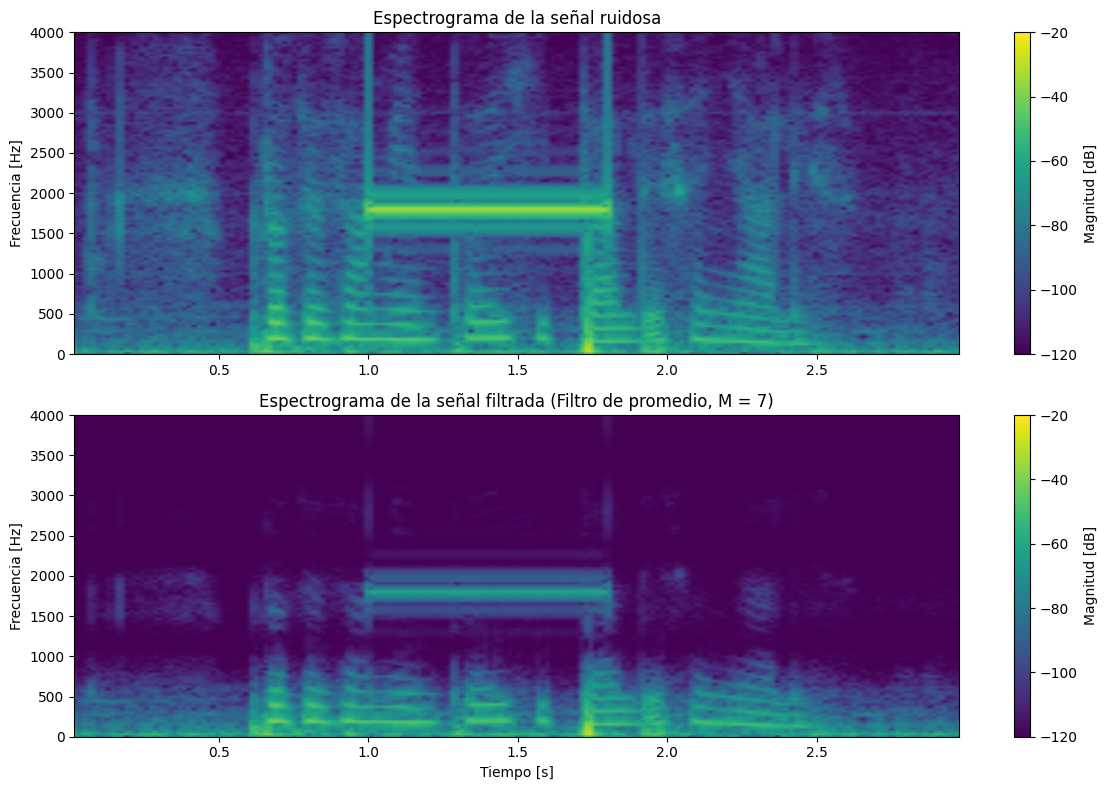

Audio ruidoso:


Audio filtrado:


In [7]:
import numpy as np
import matplotlib.pyplot as plt
import librosa
from scipy.signal import filtfilt, spectrogram
from IPython.display import Audio, display

x_ruidosa_filepath = "audio_noisy.wav" # Lectura del audio
x, fs = librosa.load(x_ruidosa_filepath, sr=None)

M = 7 # Filtrado con filtro de promedio (M = 7)
b, a = np.ones(M) / M, [1]
x_filtrada = filtfilt(b, a, x)

f1, t1, Sxx1 = spectrogram(x, fs=fs, nperseg=256, noverlap=128) # espectrograma ruidosa
f2, t2, Sxx2 = spectrogram(x_filtrada, fs=fs, nperseg=256, noverlap=128) # espectrograma filtrada
vmin, vmax = -120, -20
fig, ax = plt.subplots(2, 1, figsize=(12, 8))

im1 = ax[0].pcolormesh(t1, f1, 10*np.log10(Sxx1 + 1e-12),
                       shading='gouraud', vmin=vmin, vmax=vmax)
ax[0].set_title('Espectrograma de la señal ruidosa'); ax[0].set_ylabel('Frecuencia [Hz]')
ax[0].set_ylim([0, 4000])
cbar1 = fig.colorbar(im1, ax=ax[0]); cbar1.set_label('Magnitud [dB]')

im2 = ax[1].pcolormesh(t2, f2, 10*np.log10(Sxx2 + 1e-12),
                       shading='gouraud', vmin=vmin, vmax=vmax)
ax[1].set_title('Espectrograma de la señal filtrada (Filtro de promedio, M = 7)')
ax[1].set_xlabel('Tiempo [s]'); ax[1].set_ylabel('Frecuencia [Hz]')
ax[1].set_ylim([0, 4000])
cbar2 = fig.colorbar(im2, ax=ax[1]); cbar2.set_label('Magnitud [dB]')

plt.tight_layout();plt.show()

print("Audio ruidoso:")
display(Audio(x, rate=fs)) # play audio ruidoso
print("Audio filtrado:")
display(Audio(x_filtrada, rate=fs)) # play audio filtrado

In [8]:
from scipy.io.wavfile import write
write("audio_promedio.wav", fs, x_filtrada.astype(np.float32))

# **Ejemplo 14.  Filtrado con filtro FIR utilizando método ventaneo**

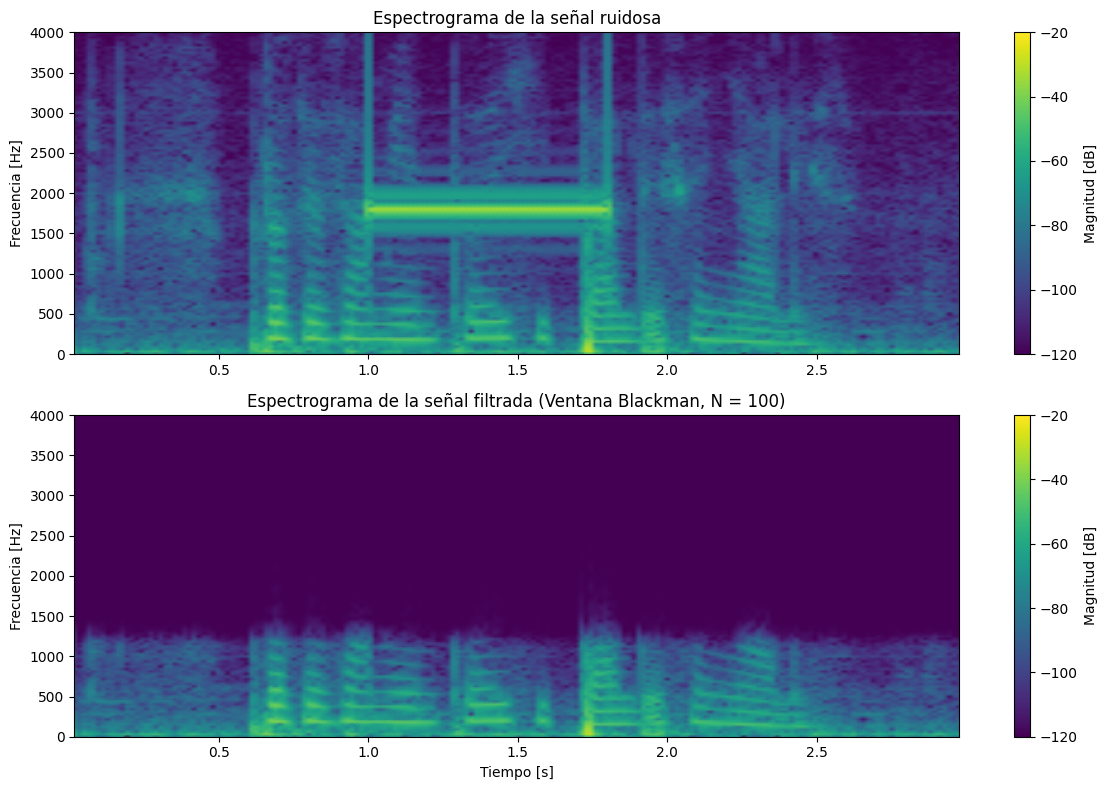

Audio ruidoso:


Audio filtrado:


In [9]:
from scipy.signal import firwin, filtfilt

fc = 1200
orden = 100 # Se denomina como N

x_ruidosa_filepath = "audio_noisy.wav" # Lectura del audio
x, fs = librosa.load(x_ruidosa_filepath, sr=None)


b = firwin(numtaps=orden+1, cutoff=fc, fs=fs, window='blackman')
a = [1]

x_filtrada_blackman = filtfilt(b, a, x)

f1, t1, Sxx1 = spectrogram(x, fs=fs, nperseg=256, noverlap=128) # espectrograma ruidosa
f2, t2, Sxx2 = spectrogram(x_filtrada_blackman, fs=fs, nperseg=256, noverlap=128) # espectrograma filtrada
vmin, vmax = -120, -20
fig, ax = plt.subplots(2, 1, figsize=(12, 8))

im1 = ax[0].pcolormesh(t1, f1, 10*np.log10(Sxx1 + 1e-12),
                       shading='gouraud', vmin=vmin, vmax=vmax)
ax[0].set_title('Espectrograma de la señal ruidosa'); ax[0].set_ylabel('Frecuencia [Hz]')
ax[0].set_ylim([0, 4000])
cbar1 = fig.colorbar(im1, ax=ax[0]); cbar1.set_label('Magnitud [dB]')

im2 = ax[1].pcolormesh(t2, f2, 10*np.log10(Sxx2 + 1e-12),
                       shading='gouraud', vmin=vmin, vmax=vmax)
ax[1].set_title('Espectrograma de la señal filtrada (Ventana Blackman, N = 100)')
ax[1].set_xlabel('Tiempo [s]'); ax[1].set_ylabel('Frecuencia [Hz]')
ax[1].set_ylim([0, 4000])
cbar2 = fig.colorbar(im2, ax=ax[1]); cbar2.set_label('Magnitud [dB]')

plt.tight_layout();plt.show()

print("Audio ruidoso:")
display(Audio(x, rate=fs)) # play audio ruidoso
print("Audio filtrado:")
display(Audio(x_filtrada_blackman, rate=fs)) # play audio filtrado

In [10]:
from scipy.io.wavfile import write
write("audio_blackman.wav", fs, x_filtrada_blackman.astype(np.float32))

# **Ejemplo 15.  Filtrado con filtro IIR Butterworth aplicando Transformada Bilineal**

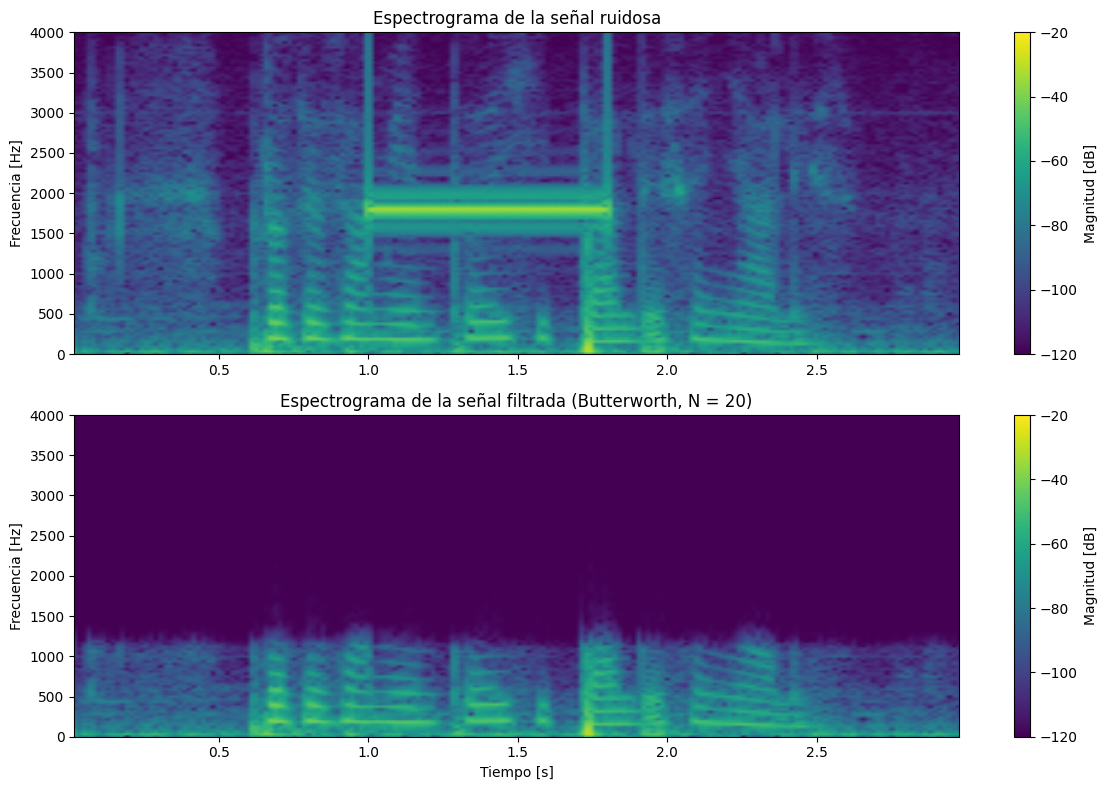

Audio ruidoso:


Audio filtrado:


In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.io import wavfile
from scipy.signal import spectrogram # Import spectrogram
from IPython.display import Audio, display # Import Audio and display

x_ruidosa_filepath = "audio_noisy.wav" # Lectura del audio  # Cambiar por el nombre del archivo
fc = 1200                              # Frecuencia de corte [Hz]
orden = 20                             # Orden del filtro Butterworth

x, fs = librosa.load(x_ruidosa_filepath, sr=None)
wc = 2 * np.pi * fc        # Frecuencia de corte analógica [rad/s]

b_a, a_a = signal.butter(orden, wc, btype="low",analog=True)
b_z, a_z = signal.bilinear(b_a, a_a, fs=fs)
x_filtrada_butterworth = signal.filtfilt(b_z, a_z, x)

f1, t1, Sxx1 = spectrogram(x, fs=fs, nperseg=256, noverlap=128) # espectrograma ruidosa
f2, t2, Sxx2 = spectrogram(x_filtrada_butterworth, fs=fs, nperseg=256, noverlap=128) # espectrograma filtrada
vmin, vmax = -120, -20
fig, ax = plt.subplots(2, 1, figsize=(12, 8))
im1 = ax[0].pcolormesh(t1, f1, 10*np.log10(Sxx1 + 1e-12),
                       shading='gouraud', vmin=vmin, vmax=vmax)
ax[0].set_title('Espectrograma de la señal ruidosa'); ax[0].set_ylabel('Frecuencia [Hz]')
ax[0].set_ylim([0, 4000])
cbar1 = fig.colorbar(im1, ax=ax[0]); cbar1.set_label('Magnitud [dB]')
im2 = ax[1].pcolormesh(t2, f2, 10*np.log10(Sxx2 + 1e-12),
                       shading='gouraud', vmin=vmin, vmax=vmax)
ax[1].set_title('Espectrograma de la señal filtrada (Butterworth, N = 20)')
ax[1].set_xlabel('Tiempo [s]'); ax[1].set_ylabel('Frecuencia [Hz]')
ax[1].set_ylim([0, 4000])
cbar2 = fig.colorbar(im2, ax=ax[1]); cbar2.set_label('Magnitud [dB]')

plt.tight_layout();plt.show()

print("Audio ruidoso:")
display(Audio(x, rate=fs)) # play audio ruidoso
print("Audio filtrado:")
display(Audio(x_filtrada_blackman, rate=fs)) # play audio filtrado

In [12]:
from scipy.io.wavfile import write
write("audio_butterworth.wav", fs, x_filtrada_butterworth.astype(np.float32))

# **Ejemplo 16: Filtrado mediante filtro Leaky**

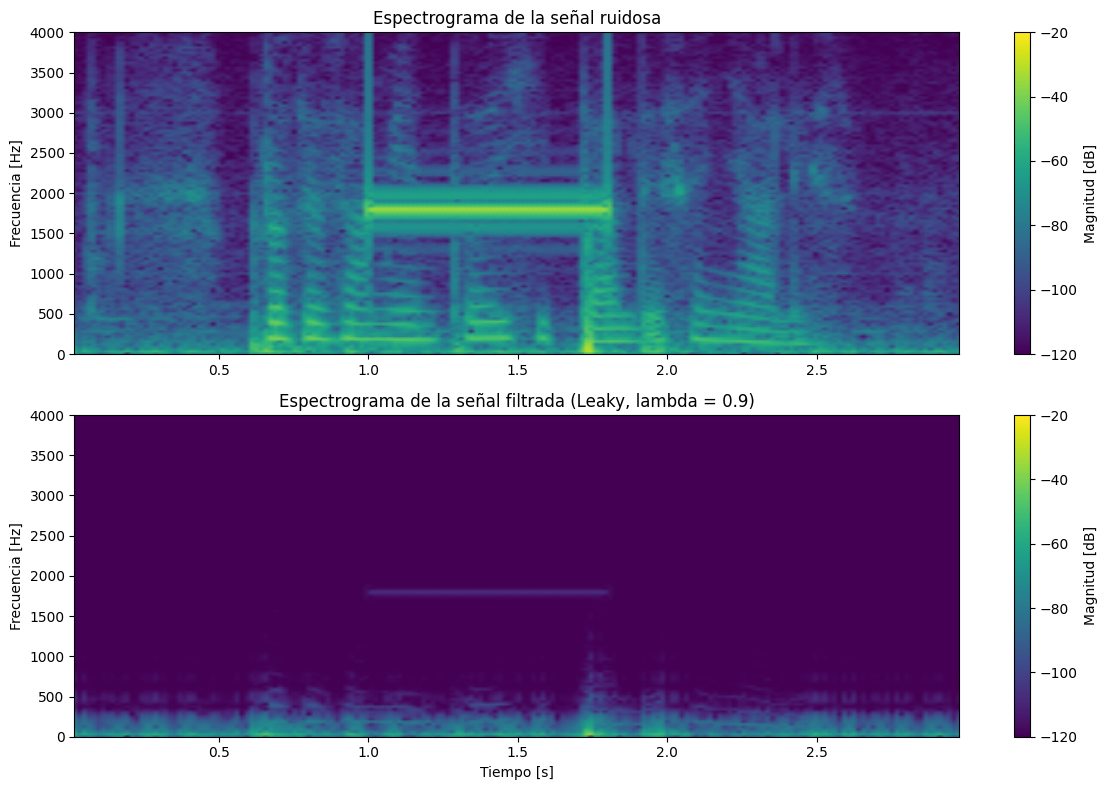

Audio ruidoso:


Audio filtrado:


In [13]:
import numpy as np
import matplotlib.pyplot as plt
import librosa
from scipy.signal import lfilter, spectrogram
from scipy.io.wavfile import write

x_ruidosa_filepath = "audio_noisy.wav"

x, fs = librosa.load(x_ruidosa_filepath, sr=None)

lambda_ = 0.98 # comprendido entre 0 y 1. Más cercano a 1 mayor el suavizado de la señal
b_leaky = [1 - lambda_]
a_leaky = [1, -lambda_]

x_filtrada_leaky = signal.filtfilt(b_leaky, a_leaky, x)

f1, t1, Sxx1 = spectrogram(x, fs=fs, nperseg=256, noverlap=128) # espectrograma ruidosa
f2, t2, Sxx2 = spectrogram(x_filtrada_leaky, fs=fs, nperseg=256, noverlap=128) # espectrograma filtrada
vmin, vmax = -120, -20
fig, ax = plt.subplots(2, 1, figsize=(12, 8))
im1 = ax[0].pcolormesh(t1, f1, 10*np.log10(Sxx1 + 1e-12),
                       shading='gouraud', vmin=vmin, vmax=vmax)
ax[0].set_title('Espectrograma de la señal ruidosa'); ax[0].set_ylabel('Frecuencia [Hz]')
ax[0].set_ylim([0, 4000])
cbar1 = fig.colorbar(im1, ax=ax[0]); cbar1.set_label('Magnitud [dB]')
im2 = ax[1].pcolormesh(t2, f2, 10*np.log10(Sxx2 + 1e-12),
                       shading='gouraud', vmin=vmin, vmax=vmax)
ax[1].set_title('Espectrograma de la señal filtrada (Leaky, lambda = 0.9)')
ax[1].set_xlabel('Tiempo [s]'); ax[1].set_ylabel('Frecuencia [Hz]')
ax[1].set_ylim([0, 4000])
cbar2 = fig.colorbar(im2, ax=ax[1]); cbar2.set_label('Magnitud [dB]')

plt.tight_layout();plt.show()

print("Audio ruidoso:")
display(Audio(x, rate=fs)) # play audio ruidoso
print("Audio filtrado:")
display(Audio(x_filtrada_blackman, rate=fs)) # play audio filtrado

In [14]:
from scipy.io.wavfile import write
write("audio_leaky.wav", fs, x_filtrada_leaky.astype(np.float32))

# **Ejemplo 17.  Análisis comparativo de cuatro tipos de filtro para el caso de estudio:  filtro de promedio, filtro con ventana Blackman, filtro Butterworth con Transformada Bilineal, y filtro Leaky**

**Criterio 1:  Energía residual**

In [15]:
import numpy as np
from scipy.signal import spectrogram

def energia_residual_tono(x, fs, f_tono=1800, ancho_banda=50):
    """
    Calcula la energía residual alrededor de un tono interferente
    usando el espectrograma de la señal.

    Parámetros:
    x : señal de audio
    fs : frecuencia de muestreo
    f_tono : frecuencia del tono interferente
    ancho_banda : ancho a cada lado de la frecuencia central

    Retorna:
    energia_tono : energía acumulada en la banda del tono
    """

    f, t, Sxx = spectrogram(x, fs=fs, nperseg=512, noverlap=256)
    f_min = f_tono - ancho_banda
    f_max = f_tono + ancho_banda
    idx_banda = (f >= f_min) & (f <= f_max)
    energia_tono = np.sum(Sxx[idx_banda, :])
    return energia_tono

y_promedio, fs = librosa.load("audio_promedio.wav", sr=None)
y_blackman, fs = librosa.load("audio_blackman.wav", sr=None)
y_butter, fs = librosa.load("audio_butterworth.wav", sr=None)
y_leaky, fs = librosa.load("audio_leaky.wav", sr=None)

E_promedio = energia_residual_tono(y_promedio, fs)
E_blackman = energia_residual_tono(y_blackman, fs)
E_butter = energia_residual_tono(y_butter, fs)
E_leaky = energia_residual_tono(y_leaky, fs)

print("Energía residual del tono de 1800 Hz")
print(f"Filtro de promedio: {E_promedio:.6e}")
print(f"Filtro Blackman: {E_blackman:.6e}")
print(f"Filtro Butterworth: {E_butter:.6e}")
print(f"Filtro Leaky: {E_leaky:.6e}")

Energía residual del tono de 1800 Hz
Filtro de promedio: 5.432817e-05
Filtro Blackman: 6.927825e-13
Filtro Butterworth: 6.287068e-13
Filtro Leaky: 1.518678e-09


**Criterio 2: Energía conservada de la señal de voz**

In [16]:
import numpy as np
from scipy.signal import spectrogram

def energia_banda_voz(x, fs, f_min=0, f_max=1200):
    """
    Calcula la energía conservada en la banda útil de la voz
    a partir del espectrograma de la señal.

    Parámetros:
    x : señal de audio
    fs : frecuencia de muestreo
    f_min : frecuencia mínima de la banda útil
    f_max : frecuencia máxima de la banda útil

    Retorna:
    energia_voz : energía acumulada en la banda de voz
    """

    f, t, Sxx = spectrogram(x, fs=fs, nperseg=512, noverlap=256)
    idx_banda = (f >= f_min) & (f <= f_max)
    energia_voz = np.sum(Sxx[idx_banda, :])
    return energia_voz

y_promedio, fs = librosa.load("audio_promedio.wav", sr=None)
y_blackman, fs = librosa.load("audio_blackman.wav", sr=None)
y_butter, fs = librosa.load("audio_butterworth.wav", sr=None)
y_leaky, fs = librosa.load("audio_leaky.wav", sr=None)

Evoz_promedio = energia_banda_voz(y_promedio, fs)
Evoz_blackman = energia_banda_voz(y_blackman, fs)
Evoz_butter = energia_banda_voz(y_butter, fs)
Evoz_leaky = energia_banda_voz(y_leaky, fs)

print("Energía conservada en la banda útil de la voz")
print(f"Filtro de promedio: {Evoz_promedio:.6e}")
print(f"Filtro Blackman: {Evoz_blackman:.6e}")
print(f"Filtro Butterworth: {Evoz_butter:.6e}")
print(f"Filtro Leaky: {Evoz_leaky:.6e}")

Energía conservada en la banda útil de la voz
Filtro de promedio: 7.453849e-03
Filtro Blackman: 8.685923e-03
Filtro Butterworth: 8.682669e-03
Filtro Leaky: 7.247906e-04


Libro: Procesamiento Digital de Voz e Imágenes  en la Era de la Inteligencia Artificial

---


Versión: 2026 – Material complementario para Google Colab.